# Exercise 3 : Linear Regression

---

### Essential Libraries

Let us begin by importing the essential Python Libraries.

> NumPy : Library for Numeric Computations in Python  
> Pandas : Library for Data Acquisition and Preparation  
> Matplotlib : Low-level library for Data Visualization  
> Seaborn : Higher-level library for Data Visualization  

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

---

## Setup : Import the Dataset

Dataset from Kaggle : The **"House Prices"** competition     
Source: https://www.kaggle.com/c/house-prices-advanced-regression-techniques

The dataset is `train.csv`; hence we use the `read_csv` function from Pandas.  
Immediately after importing, take a quick look at the data using the `head` function.

In [2]:
houseData = pd.read_csv('train.csv')
houseData.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---

## Problem 1 : Predicting SalePrice using GrLivArea

Extract the required variables from the dataset, as mentioned in the problem.     

In [3]:
houseGrLivArea = pd.DataFrame(houseData['GrLivArea'])
houseSalePrice = pd.DataFrame(houseData['SalePrice'])

**a) Plot `houseSalePrice` against `houseGrLivArea` using standard jointplot, and note the strong linear relationship.
Remember the correlation coefficient between these two variables from the last Example Class? Check again.**

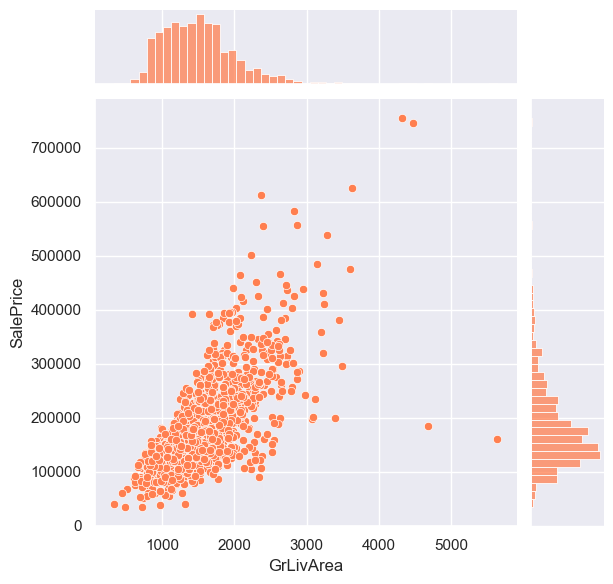

In [4]:
sb.jointplot(x=houseGrLivArea['GrLivArea'], y=houseSalePrice['SalePrice'], height = 6, color = "coral")

**b) Import Linear Regression model from Scikit-Learn : `from sklearn.linear_model import LinearRegression`**

In [8]:
# Import LinearRegression model from Scikit-Learn
from sklearn.linear_model import LinearRegression

# Create a Linear Regression object
linreg = LinearRegression()

Prepare both the datasets by splitting in Train and Test sets.   
Train Set with 1100 samples and Test Set with 360 samples.

**c) Partition both datasets `houseGrLivArea` and `houseSalePrice` into Train (1100 rows) and Test (360 rows) sets.**

**Train datasets : `houseGrLivArea_train` and `houseSalePrice_train` (check both have 1100 rows)**

**Test datasets : `houseGrLivArea_test` and `houseSalePrice_test` (check both have 360 rows)**

In [9]:
# Split the dataset into Train and Test       
houseGrLivArea_train = pd.DataFrame(houseGrLivArea[:1100])
houseGrLivArea_test  = pd.DataFrame(houseGrLivArea[-360:])
houseSalePrice_train = pd.DataFrame(houseSalePrice[:1100])
houseSalePrice_test  = pd.DataFrame(houseSalePrice[-360:])


from sklearn.model_selection import train_test_split

# Split the Dataset into Train and Test
#X_train, X_test, y_train, y_test = train_test_split(hp, total, test_size = 360/1460)

# Check the sample sizes
print("Train Set :", houseGrLivArea_train.shape, houseSalePrice_train.shape)
print("Test Set  :", houseGrLivArea_test.shape, houseSalePrice_test.shape)

Train Set : (1100, 1) (1100, 1)
Test Set  : (360, 1) (360, 1)


**d) Training : Fit a Linear Regression model with X = `houseGrLivArea_train` and y = `houseSalePrice_train`**

In [10]:
linreg.fit(X=houseGrLivArea_train, y=houseSalePrice_train)

LinearRegression()

**e) Print the coefficients of the Linear Regression model you just fit, and plot the Regression line on a Scatterplot
of houseGrLivArea_train and houseSalePrice_train using the standard slope-intercept form of straight line.**

In [11]:
print('Intercept \t: b = ', linreg.intercept_)
print('Coefficients \t: a = ', linreg.coef_)

Intercept 	: b =  [9498.33463562]
Coefficients 	: a =  [[113.88950443]]


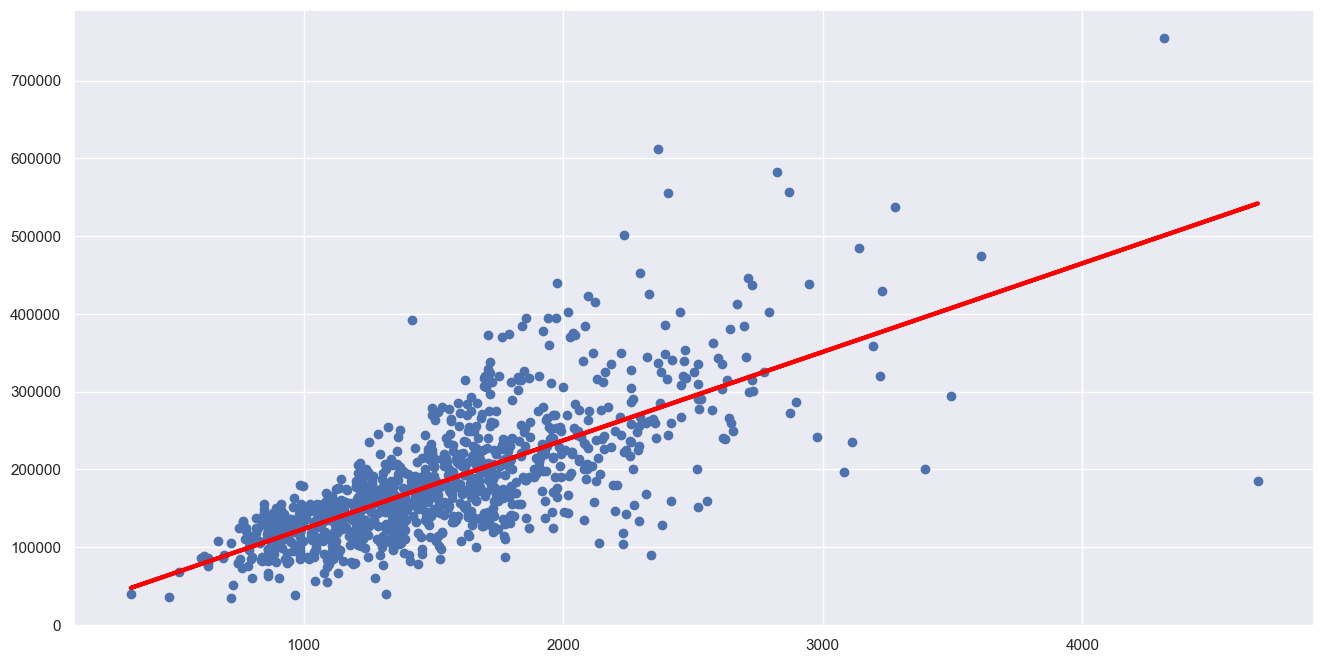

In [12]:
# Formula for the Regression line
regline_x = houseGrLivArea_train
regline_y = linreg.intercept_ + linreg.coef_ * houseGrLivArea_train
houseSalePrice_train_pred = linreg.predict(houseGrLivArea_train)
houseSalePrice_test_pred = linreg.predict(houseGrLivArea_test)


# Plot the Linear Regression line
f, axes = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
plt.scatter(x=houseGrLivArea_train, y=houseSalePrice_train)
plt.plot(regline_x, regline_y, color='red', linewidth = 3)
plt.show()

**f) Predict `SalePrice` for the test dataset `houseGrLivArea_test` using the Linear Regression model, and plot the
predictions on the Scatterplot of `houseGrLivArea_test` and `houseSalePrice_test` to visualize the accuracy.**

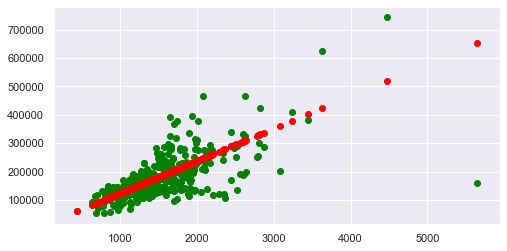

In [11]:
# Predict SalePrice values corresponding to GrLivArea
houseSalePrice_test_pred = linreg.predict(houseGrLivArea_test)

# Plot the Predictions
f, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
plt.scatter(x=houseGrLivArea_test, y=houseSalePrice_test, color = "green")
plt.scatter(x=houseGrLivArea_test, y=houseSalePrice_test_pred, color = "red")
plt.show()

**g) Find the Explained Variance (R^2) of the model on the Train set and on the Test set to check Goodness of Fit.**

In [12]:
print("Explained Variance (R^2) \t:", linreg.score(houseGrLivArea_train, houseSalePrice_train))
print("Explained Variance (R^2) \t:", linreg.score(houseGrLivArea_test, houseSalePrice_test))

Explained Variance (R^2) 	: 0.5317704755454566
Explained Variance (R^2) 	: 0.40117720006925806


#### You should also try the following

* Convert `SalePrice` to `log(SalePrice)` in the beginning and then use it for Regression     
  Code : `houseSalePrice = pd.DataFrame(np.log(houseData['SalePrice']))`    
  
* Perform a *Random Train-Test Split* on the dataset before you start with the Regression      
  Note : Check the preparation notebook `M3 LinearRegression.ipynb` for the code

## ---

## Problem 2 : Predicting SalePrice using Multiple Variables

Extract the required variables from the dataset, and then perform Multi-Variate Regression.     

In [13]:
housePredictor = pd.DataFrame(houseData[['GrLivArea','LotArea','TotalBsmtSF','GarageArea']])
houseSalePrice = pd.DataFrame(houseData['SalePrice'])

#### Linear Regression on SalePrice vs Predictor

In [14]:
# Import LinearRegression model from Scikit-Learn
from sklearn.linear_model import LinearRegression

# Split the dataset into Train and Test       
# Split the Dataset into Train and Test
housePredictor_train, housePredictor_test, houseSalePrice_train, houseSalePrice_test = train_test_split(housePredictor, houseSalePrice, test_size = 0.25)


# Create a Linear Regression object
linreg = LinearRegression()

# Train the Linear Regression model
linreg.fit(X=housePredictor_train, y=houseSalePrice_train)

LinearRegression()

#### Coefficients of the Linear Regression Model

Note that you CANNOT visualize the model as a line on a 2D plot, as it is a multi-dimensional surface.

In [18]:
print('Intercept \t: b = ', linreg.intercept_)
print('Coefficients \t: a = ', linreg.coef_)

Intercept 	: b =  [-15804.94451691]
Coefficients 	: a =  [[6.27026849e+01 4.71091742e-02 4.65917346e+01 1.08355406e+02]]


#### Prediction of Response based on the Predictor

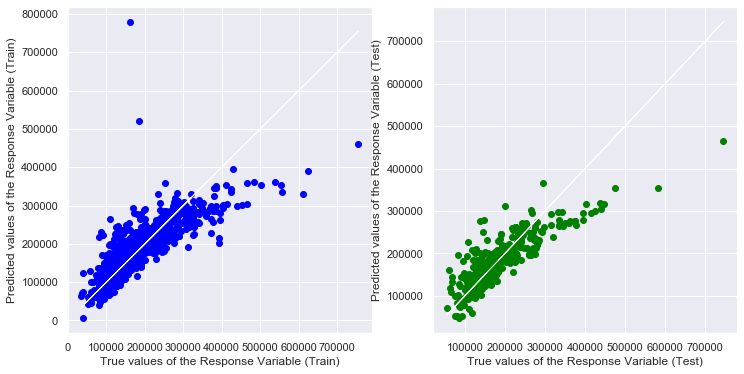

In [16]:
# Predict SalePrice values corresponding to GrLivArea
houseSalePrice_train_pred = linreg.predict(housePredictor_train)
houseSalePrice_test_pred = linreg.predict(housePredictor_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(houseSalePrice_train, houseSalePrice_train_pred, color = "blue")
axes[0].plot(houseSalePrice_train, houseSalePrice_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(houseSalePrice_test, houseSalePrice_test_pred, color = "green")
axes[1].plot(houseSalePrice_test, houseSalePrice_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

#### Goodness of Fit of the Linear Regression Model

In [19]:
print("Explained Variance (R^2) on Train Set \t:", linreg.score(X=housePredictor_train, y=houseSalePrice_train))
print("Explained Variance (R^2) on Test Set \t:", linreg.score(X=housePredictor_test, y=houseSalePrice_test))

Explained Variance (R^2) on Train Set 	: 0.6413633289088463
Explained Variance (R^2) on Test Set 	: 0.7120596095935926


---

## Interpretation and Discussion

Now that you have performed Linear Regression of `SalePrice` against the four variables `GrLivArea`, `LotArea`, `TotalBsmtSF`, `GarageArea`, compare-and-contrast the Explained Variance (R^2) to determine which model is the best in order to predict `SalePrice`. What do you think?

`GrLivingArea_train` 

Explained Variance (R^2) on Train Set : 0.5317704755454566

Explained Variance (R^2) on Test Set	: 0.40117720006925806

`LotArea` 

Explained Variance (R^2) on Train Set : 0.06996047063721678

Explained Variance (R^2) : 0.0661786844889618

`TotalBsmtSF` 

Explained Variance (R^2) on Train Set 	: 0.40965154133422405

Explained Variance (R^2) on Test Set 	: 0.26305378699344206

`GarageArea`

Explained Variance (R^2) on Train Set 	: 0.40526589947579356

Explained Variance (R^2) on Test Set 	: 0.33415894889143827

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_x = scaler.fit(housePredictor)